In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ai_writing_detection_dataset.csv')

print(f'Строк: {df.shape[0]}, Столбцов: {df.shape[1]}')
df.info()
df.describe(include='all').T


Строк: 10200, Столбцов: 20
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               10200 non-null  object 
 1   Submission_Type          10200 non-null  object 
 2   Academic_Level           10200 non-null  object 
 3   Primary_Language         10200 non-null  object 
 4   Word_Count               10200 non-null  int64  
 5   Average_Sentence_Length  10200 non-null  float64
 6   Grammar_Errors           10200 non-null  int64  
 7   Vocabulary_Richness      10200 non-null  float64
 8   Passive_Voice_Ratio      10200 non-null  float64
 9   Reading_Level            10200 non-null  float64
 10  Editing_Time             9311 non-null   float64
 11  Revision_Count           8687 non-null   float64
 12  Typing_Speed             9197 non-null   float64
 13  Plagiarism_Score         9387 non-null   float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,10200,10000,16959e76,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Submission_Type,10200,4,Essay,4009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic_Level,10200,3,Undergraduate,6218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Primary_Language,10200,2,Native,7687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Word_Count,10200.0,NaN,NaN,NaN,1201.668627,395.173748,300.0,925.0,1196.0,1471.0,2588.0
Average_Sentence_Length,10200.0,NaN,NaN,NaN,16.941588,4.6356,5.0,13.62,17.08,20.64,33.62
Grammar_Errors,10200.0,NaN,NaN,NaN,7.336275,5.049967,0.0,5.0,7.0,9.0,78.0
Vocabulary_Richness,10200.0,NaN,NaN,NaN,0.622392,0.098764,0.29,0.55,0.62,0.7,0.9
Passive_Voice_Ratio,10200.0,NaN,NaN,NaN,0.204774,0.096819,0.0,0.14,0.2,0.27,0.52
Reading_Level,10200.0,NaN,NaN,NaN,11.479884,2.536711,5.0,9.7,11.58,13.42,20.0


In [2]:
df.head(3)

,Student_ID,Submission_Type,Academic_Level,Primary_Language,Word_Count,Average_Sentence_Length,Grammar_Errors,Vocabulary_Richness,Passive_Voice_Ratio,Reading_Level,Editing_Time,Revision_Count,Typing_Speed,Plagiarism_Score,Citation_Count,Punctuation_Density,Sentence_Complexity,Font_Family,Submission_Hour,Is_AI_Assisted
0,16959e76,Lab_Report,Postgraduate,Native,1552,16.90,8,0.62,0.11,11.85,129.05,16.0,24.70,3.02,0.0,0.08,2.01,Arial,18,0
1,0a304e7f,Research_Paper,Undergraduate,Native,950,16.71,5,0.47,0.31,10.34,236.60,23.0,38.84,1.71,15.0,0.07,1.72,Helvetica,15,0
2,6e629f9f,Essay,Undergraduate,Non_Native,1103,22.10,1,0.76,0.38,14.35,4.72,4.0,0.00,0.41,0.0,0.08,2.35,Arial,17,1


In [3]:
# очистка

print('Полных дублей строк:', df.duplicated().sum())
print('Дублей Student_ID:', df['Student_ID'].duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print('\nПосле удаления дублей:')
print('Строк:', df.shape[0])
print('Полных дублей осталось:', df.duplicated().sum())
print('Дублей Student_ID осталось:', df['Student_ID'].duplicated().sum())

Полных дублей строк: 200
Дублей Student_ID: 200

После удаления дублей:
Строк: 10000
Полных дублей осталось: 0
Дублей Student_ID осталось: 0


было 200 полных дублей строк, все они совпадали и по Student_ID - после удаления дублей по ID тоже не осталось. Значит, это не студенты с несколькими сдачами, а просто задублированные записи.


In [4]:
df.groupby('Is_AI_Assisted')['Typing_Speed'].describe()

missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('missing > 0').sort_values('pct', ascending=False)

,missing,pct
Revision_Count,1485,14.85
Typing_Speed,984,9.84
Citation_Count,972,9.72
Editing_Time,867,8.67
Plagiarism_Score,800,8.00


5 колонок с пропусками, и все примерно в диапазоне 8-15% от строк

In [5]:
for col in ['Editing_Time', 'Revision_Count', 'Typing_Speed', 'Plagiarism_Score', 'Citation_Count']:
    print(col, df.groupby('Is_AI_Assisted')[col].apply(lambda s: s.isna().mean()).round(3).to_dict())

Editing_Time {0: 0.085, 1: 0.097}
Revision_Count {0: 0.151, 1: 0.135}
Typing_Speed {0: 0.099, 1: 0.093}
Plagiarism_Score {0: 0.08, 1: 0.079}
Citation_Count {0: 0.096, 1: 0.106}


доля пропусков почти одинакова в обоих классах - пропуски не несут информации о таргете, можно спокойно импутировать медианой.

Is_AI_Assisted
0    0.8552
1    0.1448
Name: proportion, dtype: float64


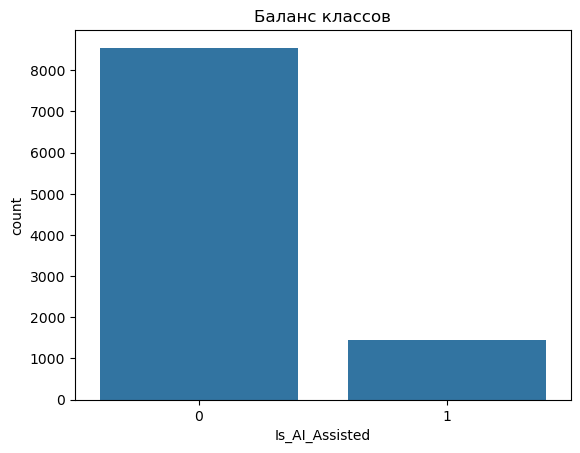

In [6]:
print(df['Is_AI_Assisted'].value_counts(normalize=True))

sns.countplot(data=df, x='Is_AI_Assisted')
plt.title('Баланс классов')
plt.show()

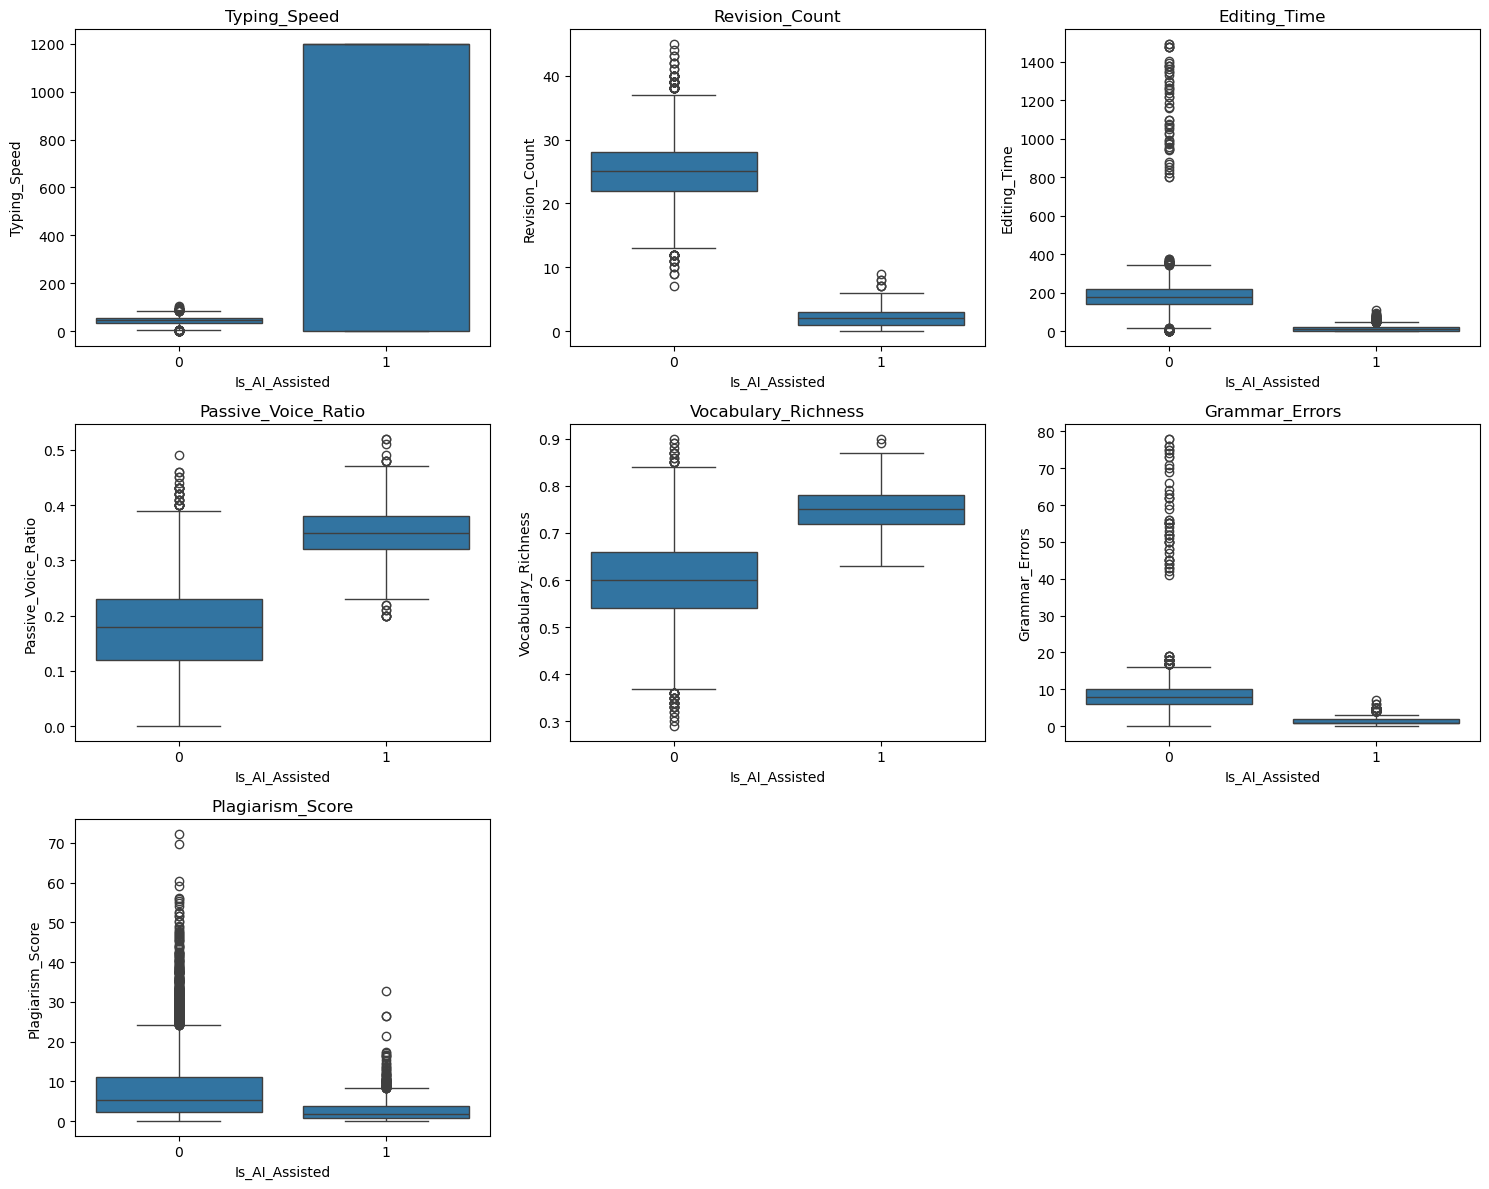

In [7]:
# боксплоты ключевых фичей (сводная сетка, без дублей)

key_features = ['Typing_Speed', 'Revision_Count', 'Editing_Time',
                 'Passive_Voice_Ratio', 'Vocabulary_Richness', 'Grammar_Errors',
                 'Plagiarism_Score']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), key_features):
    sns.boxplot(data=df, x='Is_AI_Assisted', y=col, ax=ax)
    ax.set_title(col)
for ax in axes.flatten()[len(key_features):]:
    ax.axis('off')  # это скрыть пустые сабплоты
plt.tight_layout()
plt.show()

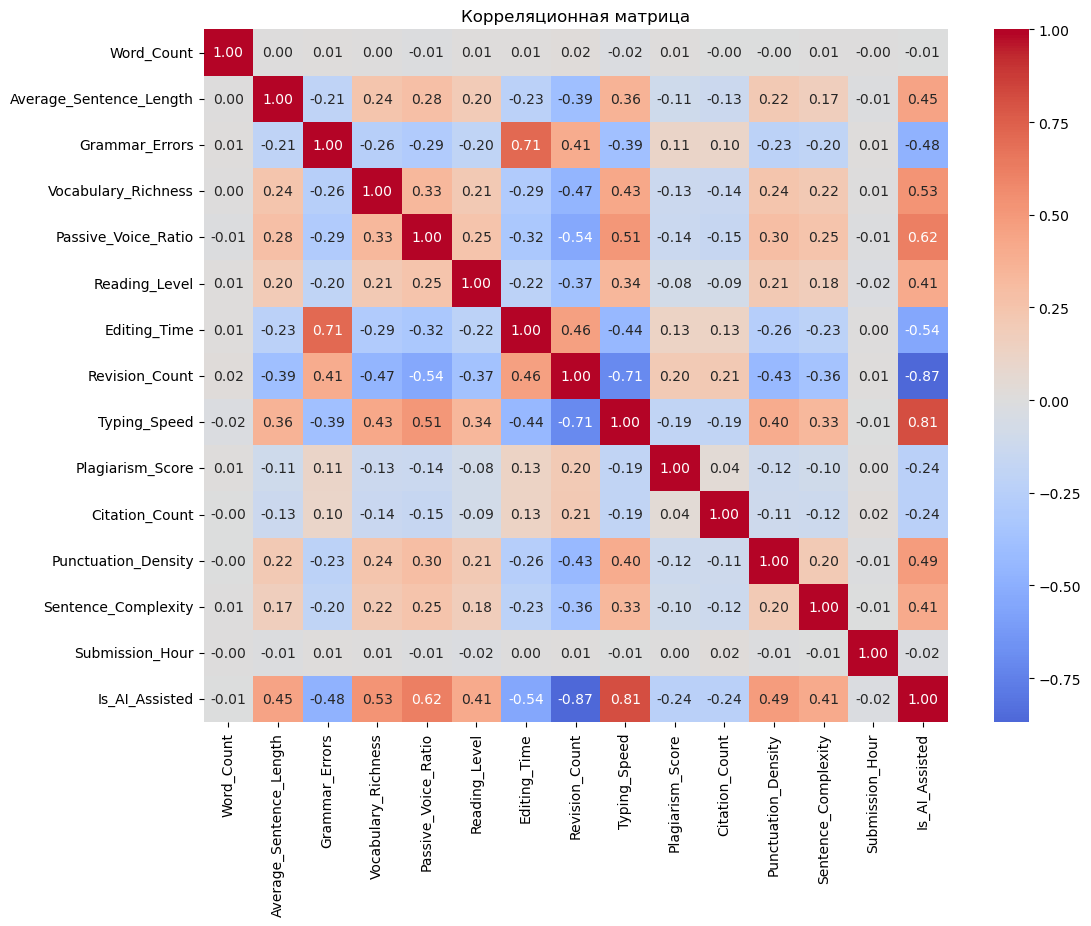

In [8]:
# корреляционная матрица

numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 9))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.show()

По матрице очень хорошо видно, какие большие показатели у Typing speed и Revision count. Корреляция с таргетом.
Сильнее всего с Is_AI_Assisted связаны поведенческие фичи: Revision_Count (r = -0.87) и Typing_Speed (r = +0.81), у AI-сдач почти нет правок и аномально высокая скорость печати (фактически вставка текста), у человеческих — наоборот. 

Следом идёт Passive_Voice_Ratio (+0.62) и Editing_Time (-0.54). Лингвистические фичи — Vocabulary_Richness (+0.53), Punctuation_Density (+0.49), Grammar_Errors (-0.48), Average_Sentence_Length (+0.45), Reading_Level (+0.41), Sentence_Complexity (+0.41) - коррелируют умеренно, но стабильно. Citation_Count и Plagiarism_Score дают слабый сигнал (~-0.24), а Word_Count и Submission_Hour практически не связаны с таргетом. Они нам вряд ли будут полезны.

Мультиколлинеарность.
Среди самих фичей заметны две сильные пары: Grammar_Errors и Editing_Time (r = 0.71) — чем больше ошибок, тем дольше редактируют текст, что логично для человеческого письма; и Revision_Count с Typing_Speed (r = -0.71) — чем больше правок, тем ниже средняя скорость печати. Обе пары по сути дублируют информацию друг другу. при интерпретации feature_importance не забывать, что высокая важность одной фичи из пары может "забирать" вес у второй.

In [9]:
cat_cols = ['Submission_Type', 'Academic_Level', 'Primary_Language', 'Font_Family']

for col in cat_cols:
    print(pd.crosstab(df[col], df['Is_AI_Assisted'], normalize='index').round(3))
    print()

Is_AI_Assisted         0      1
Submission_Type                
Essay              0.852  0.148
Lab_Report         0.849  0.151
Literature_Review  0.866  0.134
Research_Paper     0.860  0.140

Is_AI_Assisted      0      1
Academic_Level              
High_School     0.863  0.137
Postgraduate    0.853  0.147
Undergraduate   0.853  0.147

Is_AI_Assisted        0      1
Primary_Language              
Native            0.857  0.143
Non_Native        0.850  0.150

Is_AI_Assisted       0      1
Font_Family                  
Arial            0.849  0.151
Calibri          0.854  0.146
Helvetica        0.857  0.143
Times New Roman  0.860  0.140



In [10]:
# Убираю не релевантные колонки чтобы модель на них не училась. Также отделяю таргет
X = df.drop(columns=['Student_ID', 'Is_AI_Assisted'])
y = df['Is_AI_Assisted']


In [11]:
from sklearn.model_selection import train_test_split

# stratify=y обязателен здесь: таргет разбалансирован (85.5%/14.5%),
# без stratify можно случайно получить train/test с разной пропорцией классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))  # доли классов должны совпадать с train

(8000, 18) (2000, 18)
Is_AI_Assisted
0    0.85525
1    0.14475
Name: proportion, dtype: float64
Is_AI_Assisted
0    0.855
1    0.145
Name: proportion, dtype: float64


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# заполняю пропуски медианой (устойчива к выбросам),
# затем масштабирую — LogisticRegression чувствительна к разным диапазонам фичей
# 
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# для категориальных: OneHotEncoder превращает, например, Font_Family в отдельные бинарные колонки (Font_Family_Arial, Font_Family_Calibri и тд)
categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# 
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

In [13]:
from sklearn.linear_model import LogisticRegression

# class_weight='balanced' компенсирует дисбаланс классов 
# иначе модель может просто предсказывать "0" почти всегда и получить высокую accuracy
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# fit делает всё сразу: impute - scale - encode - обучение модели,
# причём статистики (медианы, среднее/std для scaler) считаются только по train
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # вероятность класса 1 (AI), нужна для ROC-AUC

f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f'F1: {f1:.3f}')
print(f'ROC-AUC: {roc_auc:.3f}')
print()
print(classification_report(y_test, y_pred))  # покажет precision/recall по каждому классу отдельно

F1: 0.998
ROC-AUC: 1.000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1710
           1       1.00      1.00      1.00       290

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



Получился фактически идеальный результат, и это при том, что это только бэйслайн модель. Скорее всего потому что typing speed  editing time мега сразу палят, кто был с ИИшкой. Придется придумать, как забустить чтобы хоть что-то еще было. На этоп этапе у меня возникает вопрос: а в будущем что делать, если например, не у всех студентов будет параметр typing_speed? Допустим, не все инструменты могут это замерять, или например студент сам написал работу в блокноте, а потом скопировал и вставил и из-за этого typing speed вышел не человеческим. Тогда нужно что-то, чтобы без ситуаций где студента ложно обвинили в  использовании ИИ
энивей

In [15]:
# добавляем отношения поверх существующих фичей — обсуждали на EDA
# используем .copy(), чтобы не изменять X, полученный на прошлом этапе, "по ссылке" (подсмотрела из урока)
X_fe = X.copy()

X_fe['Errors_per_Word'] = X_fe['Grammar_Errors'] / X_fe['Word_Count']
X_fe['Revisions_per_Word'] = X_fe['Revision_Count'] / X_fe['Word_Count']
X_fe['Citations_per_Word'] = X_fe['Citation_Count'] / X_fe['Word_Count']

X_fe.head()

,Submission_Type,Academic_Level,Primary_Language,Word_Count,Average_Sentence_Length,Grammar_Errors,Vocabulary_Richness,Passive_Voice_Ratio,Reading_Level,Editing_Time,...,Typing_Speed,Plagiarism_Score,Citation_Count,Punctuation_Density,Sentence_Complexity,Font_Family,Submission_Hour,Errors_per_Word,Revisions_per_Word,Citations_per_Word
0,Lab_Report,Postgraduate,Native,1552,16.90,8,0.62,0.11,11.85,129.05,...,24.70,3.02,0.0,0.08,2.01,Arial,18,0.005155,0.010309,0.000000
1,Research_Paper,Undergraduate,Native,950,16.71,5,0.47,0.31,10.34,236.60,...,38.84,1.71,15.0,0.07,1.72,Helvetica,15,0.005263,0.024211,0.015789
2,Essay,Undergraduate,Non_Native,1103,22.10,1,0.76,0.38,14.35,4.72,...,0.00,0.41,0.0,0.08,2.35,Arial,17,0.000907,0.003626,0.000000
3,Essay,Postgraduate,Native,1189,20.00,7,0.61,0.26,10.93,NaN,...,41.92,3.06,5.0,0.05,1.68,Times New Roman,5,0.005887,0.020185,0.004205
4,Essay,Undergraduate,Native,1035,22.67,2,0.80,0.33,15.30,16.82,...,0.00,2.78,1.0,0.09,2.90,Helvetica,8,0.001932,0.001932,0.000966


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fe, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
# RandomForest, XGBoost

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier  

numeric_cols = X_fe.select_dtypes(include='number').columns.tolist()
categorical_cols = X_fe.select_dtypes(include='object').columns.tolist()

# для деревьев масштабирование не нужно (в отличие от LogisticRegression),
# но пропуски и OneHot всё равно сделаю
tree_preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

rf_model = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# scale_pos_weight — аналог class_weight для XGBoost: отношение размеров классов
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'))
])

rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Подбор гиперпараметров

In [18]:
from sklearn.model_selection import RandomizedSearchCV

# сетка для RandomForest — перебираем не всё подряд (GridSearch долго),
# а случайные комбинации (RandomizedSearch) чтоб было быстрее 
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_leaf': [1, 2, 5]
}

rf_search = RandomizedSearchCV(
    rf_model, rf_param_grid, n_iter=10, scoring='f1',
    cv=3, random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
print('Лучшие параметры RF:', rf_search.best_params_)

xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.3]
}

xgb_search = RandomizedSearchCV(
    xgb_model, xgb_param_grid, n_iter=10, scoring='f1',
    cv=3, random_state=42, n_jobs=-1
)
xgb_search.fit(X_train, y_train)
print('Лучшие параметры XGB:', xgb_search.best_params_)

best_rf = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

# Еще как альтернатива вроде есть Грид

from sklearn.model_selection import GridSearchCV

rf_grid_search = GridSearchCV(
    rf_model, rf_param_grid, scoring='f1', cv=3, n_jobs=-1
)
rf_grid_search.fit(X_train, y_train)

print('GridSearchCV лучшие параметры RF:', rf_grid_search.best_params_)
print('Совпадают с RandomizedSearchCV?', rf_grid_search.best_params_ == rf_search.best_params_)

Лучшие параметры RF: {'classifier__n_estimators': 300, 'classifier__min_samples_leaf': 5, 'classifier__max_depth': None}
Лучшие параметры XGB: {'classifier__n_estimators': 100, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.1}
GridSearchCV лучшие параметры RF: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
Совпадают с RandomizedSearchCV? False


несмотря на разные найденные комбинации гиперпараметров, итоговые метрики на тесте всё равно одинаковы (1.000/1.000) — задача настолько разделима, что качество финальной модели не чувствительно к точному подбору параметров в этом диапазоне.

In [19]:
# Сравнительная табличечка

results = []
for name, m in [('LogisticRegression (baseline)', model),
                 ('RandomForest (tuned)', best_rf),
                 ('XGBoost (tuned)', best_xgb)]:
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    results.append({
        'model': name,
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results)
results_df

,model,F1,ROC-AUC
0,LogisticRegression (baseline),0.998279,0.999998
1,RandomForest (tuned),1.000000,1.000000
2,XGBoost (tuned),1.000000,1.000000


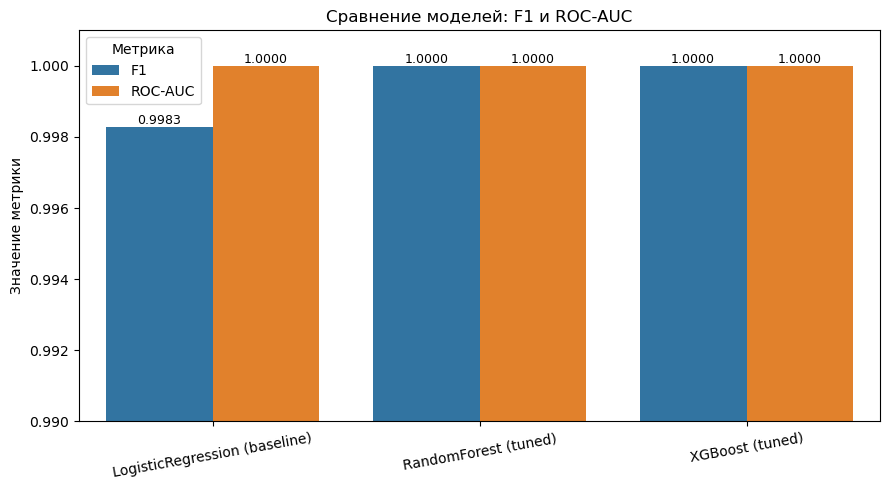

In [20]:

results_melted = results_df.melt(id_vars='model', var_name='metric', value_name='score')

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=results_melted, x='model', y='score', hue='metric')
plt.ylim(0.99, 1.001)  # зум на верхнюю часть шкалы - иначе разница вообще не будет видна
plt.title('Сравнение моделей: F1 и ROC-AUC')
plt.xlabel('')
plt.ylabel('Значение метрики')
plt.xticks(rotation=10)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=9)

plt.legend(title='Метрика')
plt.tight_layout()
plt.show()

In [21]:
# Двухмодельная система с флагом расхождения. Вторая модель не будет учитывать скорость печати, эдиты и колво правок
# это три фичи, которые считаем потенциально ненадёжными, так что схема такая: втягиваем сюда второе "мнение" и смотрим, расходятся ли мнения моделей
# вообще замысел тут такой: если модели имеют разные предикты, то текст помечается не как "ИИ" или "Человек", а то что нужна доп проверка уже вручную 

telemetry_cols = ['Typing_Speed', 'Revision_Count', 'Editing_Time']
linguistic_cols = [c for c in numeric_cols if c not in telemetry_cols]

linguistic_preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), linguistic_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# берём тот же RandomForest (лучшую модель по табличке), но без телеметрии
linguistic_model = Pipeline([
    ('preprocessor', linguistic_preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])
linguistic_model.fit(X_train, y_train)

pred_full = best_rf.predict(X_test)
pred_linguistic = linguistic_model.predict(X_test)

disagreement = pred_full != pred_linguistic
print(f'Метрики модели только на лингвистике: F1={f1_score(y_test, pred_linguistic):.3f}, ROC-AUC={roc_auc_score(y_test, linguistic_model.predict_proba(X_test)[:,1]):.3f}')
print(f'Доля расхождений между моделями: {disagreement.mean():.3f} ({disagreement.sum()} из {len(disagreement)})')

Метрики модели только на лингвистике: F1=0.998, ROC-AUC=1.000
Доля расхождений между моделями: 0.001 (1 из 2000)


У Random Forest XGBoost идентичные параметры, но я все таки выбираю Форест. Он мне больше нравится и он даёт прямой доступ к feature_importances_, что уже использовано для анализа значимости признаков (Grammar_Errors, Revision_Count, Editing_Time - топ-3 по важности). это ключевая часть выводов проекта. Плюс он здесь нужен для двухмодельной системы.

In [22]:
importances = pd.Series(
    best_rf.named_steps['classifier'].feature_importances_,
    index=best_rf.named_steps['preprocessor'].get_feature_names_out()
).sort_values(ascending=False)

importances.head(15)  # feature engineering выполнен, но из-за того, что задача уже почти идеально решается поведенческими фичами, 
# прирост от новых признаков минимален

num__Grammar_Errors             0.184260
num__Revision_Count             0.141493
num__Editing_Time               0.129918
num__Revisions_per_Word         0.127042
num__Errors_per_Word            0.094703
num__Passive_Voice_Ratio        0.079773
num__Vocabulary_Richness        0.063350
num__Typing_Speed               0.047396
num__Average_Sentence_Length    0.039971
num__Punctuation_Density        0.035804
num__Reading_Level              0.025671
num__Sentence_Complexity        0.016351
num__Citation_Count             0.006270
num__Plagiarism_Score           0.003985
num__Citations_per_Word         0.002925
dtype: float64

In [23]:
# выполни в ноутбуке — покажет версии установленных библиотек
import pandas, numpy, matplotlib, seaborn, sklearn, xgboost
for lib in [pandas, numpy, matplotlib, seaborn, sklearn, xgboost]:
    print(f'{lib.__name__}=={lib.__version__}')

pandas==2.3.3
numpy==2.3.5
matplotlib==3.10.6
seaborn==0.13.2
sklearn==1.7.2
xgboost==3.4.1


In [24]:
import os
print(os.getcwd())

C:\Users\User\anaconda_projects\a0f2b43e-0be8-4e60-b8d5-490dcf4cd5d5


In [25]:
import joblib

# сохраняем обе модели вместе в виде словаря — так один файл содержит
# всё, что нужно для двухмодельной системы с флагом расхождения
models_to_save = {
    'full_model': best_rf,
    'linguistic_model': linguistic_model,
    'telemetry_cols': telemetry_cols,  # список "ненадёжных" колонок — пригодится в app.py
    'linguistic_cols': linguistic_cols
}

joblib.dump(models_to_save, r'C:\Users\User\Desktop\my_project44\model.pkl')  # ../ потому что ноутбук лежит в notebooks/, а model.pkl должен быть в корне

print('Модель сохранена в model.pkl')

Модель сохранена в model.pkl


In [26]:
import os


# вспомнила что нужно еще data/processed. Собираю финальный обработанный датасет: X_fe (фичи после feature engineering) + таргет
processed_df = X_fe.copy()
processed_df['Is_AI_Assisted'] = y

processed_df.to_csv(r'C:\Users\User\Desktop\my_project44\data\processed\processed_data.csv', index=False)

print('Сохранено:', processed_df.shape)
processed_df.head()

Сохранено: (10000, 22)


,Submission_Type,Academic_Level,Primary_Language,Word_Count,Average_Sentence_Length,Grammar_Errors,Vocabulary_Richness,Passive_Voice_Ratio,Reading_Level,Editing_Time,...,Plagiarism_Score,Citation_Count,Punctuation_Density,Sentence_Complexity,Font_Family,Submission_Hour,Errors_per_Word,Revisions_per_Word,Citations_per_Word,Is_AI_Assisted
0,Lab_Report,Postgraduate,Native,1552,16.90,8,0.62,0.11,11.85,129.05,...,3.02,0.0,0.08,2.01,Arial,18,0.005155,0.010309,0.000000,0
1,Research_Paper,Undergraduate,Native,950,16.71,5,0.47,0.31,10.34,236.60,...,1.71,15.0,0.07,1.72,Helvetica,15,0.005263,0.024211,0.015789,0
2,Essay,Undergraduate,Non_Native,1103,22.10,1,0.76,0.38,14.35,4.72,...,0.41,0.0,0.08,2.35,Arial,17,0.000907,0.003626,0.000000,1
3,Essay,Postgraduate,Native,1189,20.00,7,0.61,0.26,10.93,NaN,...,3.06,5.0,0.05,1.68,Times New Roman,5,0.005887,0.020185,0.004205,0
4,Essay,Undergraduate,Native,1035,22.67,2,0.80,0.33,15.30,16.82,...,2.78,1.0,0.09,2.90,Helvetica,8,0.001932,0.001932,0.000966,1
